In [ ]:
import pandas as pd

# cargar excel
df = pd.read_excel("Base de datos completa.xlsx")

# convertir primera fila en headers
df.columns = df.iloc[0]

# eliminar fila de headers duplicados
df = df[1:]

# resetear indices
df = df.reset_index(drop=True)

# limpiar nombres columnas
df.columns = (
    df.columns
    .astype(str)
    .str.lower()
    .str.strip()
    .str.replace(" ", "_")
)

# revisar
print(df.columns)

Index(['trend_name', 'macrotrend', 'microtrend_level', 'source_platform',
       'brand_source', 'region', 'year', 'season', 'color_primary',
       'color_secondary', 'silhouette_main', 'silhouette_secondary',
       'texture_main', 'texture_secondary', 'pattern_type',
       'material_reference', 'mood_aesthetic', 'style_family', 'gender_focus',
       'formality_level', 'movement_level', 'volume_level', 'sensuality_level',
       'utility_level', 'romanticism_level', 'minimalism_level',
       'maximalism_level', 'commercial_adoption', 'search_interest',
       'growth_percent', 'tiktok_presence', 'pinterest_presence',
       'runway_presence', 'fast_fashion_presence', 'description'],
      dtype='object', name=0)


In [ ]:
# ==========================================
# FASHION TREND DATASET CLEANING PIPELINE
# ==========================================

# revisar tipos
print(df.dtypes)

# ------------------------------------------
# convertir niveles categoricos a numericos
# ------------------------------------------

level_map = {
    "low": 1,
    "medium": 2,
    "high": 3,
    "very high": 4
}

columns_to_map = [
    "microtrend_level",
    "commercial_adoption",
    "tiktok_presence",
    "pinterest_presence",
    "runway_presence",
    "fast_fashion_presence"
]

for col in columns_to_map:
    df[col] = (
        df[col]
        .astype(str)
        .str.lower()
        .map(level_map)
    )

# ------------------------------------------
# convertir columnas numericas
# ------------------------------------------

numeric_cols = [
    "minimalism_level",
    "maximalism_level",
    "search_interest",
    "growth_percent",
    "utility_level",
    "romanticism_level",
    "movement_level",
    "volume_level",
    "sensuality_level"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ------------------------------------------
# limpiar texto
# ------------------------------------------

text_cols = [
    "trend_name",
    "macrotrend",
    "color_primary",
    "color_secondary",
    "silhouette_main",
    "texture_main",
    "pattern_type",
    "mood_aesthetic"
]

for col in text_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.lower()
        .str.strip()
    )

# ------------------------------------------
# revisar nulos
# ------------------------------------------

print("\nVALORES NULOS:")
print(df.isnull().sum())

# ------------------------------------------
# resumen dataset
# ------------------------------------------

print("\nINFO DATASET:")
print(df.info())

print("\nESTADISTICAS:")
print(df.describe())

print("\nDATASET LIMPIO")
print(df.head())

0
trend_name               object
macrotrend               object
microtrend_level         object
source_platform          object
brand_source             object
region                   object
year                     object
season                   object
color_primary            object
color_secondary          object
silhouette_main          object
silhouette_secondary     object
texture_main             object
texture_secondary        object
pattern_type             object
material_reference       object
mood_aesthetic           object
style_family             object
gender_focus             object
formality_level          object
movement_level           object
volume_level             object
sensuality_level         object
utility_level            object
romanticism_level        object
minimalism_level         object
maximalism_level         object
commercial_adoption      object
search_interest          object
growth_percent           object
tiktok_presence          object
pinter

In [ ]:
df["trend_score"] = (
    df["runway_presence"] * 0.30 +
    df["tiktok_presence"] * 0.20 +
    df["pinterest_presence"] * 0.20 +
    df["search_interest"] * 0.30
)

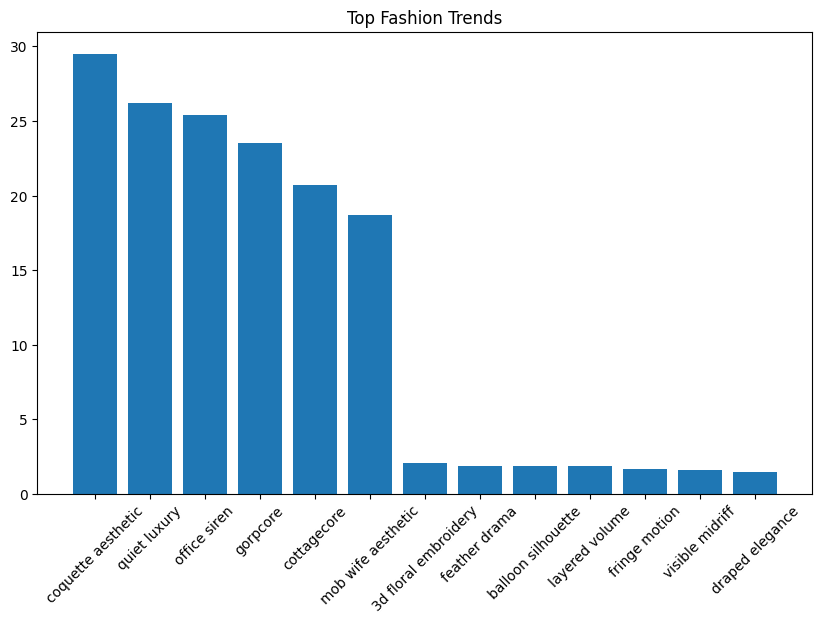

In [ ]:
import matplotlib.pyplot as plt

top_trends = df.sort_values(
    by="trend_score",
    ascending=False
)

plt.figure(figsize=(10,6))

plt.bar(
    top_trends["trend_name"],
    top_trends["trend_score"]
)

plt.xticks(rotation=45)
plt.title("Top Fashion Trends")
plt.show()